In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (7).zip to archive (7).zip


2. Extract Dataset

In [39]:
import zipfile

zip_path = '/content/archive (7) (1).zip'   # your zip file name
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


3. Check Dataset Classes

In [5]:
import os

base_path = '/content/dataset/OCTDL/OCTDL'

classes = os.listdir(base_path)

print(classes)

['RAO', 'RVO', 'NO', 'VID']


4. Install Libraries

In [6]:
!pip install -q tensorflow gradio seaborn

5. Import Libraries

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

6. Image Parameters

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 16

7. Data Augmentation

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

8. Train Data

In [10]:
train_data = train_datagen.flow_from_directory(
    base_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 405 images belonging to 4 classes.


9. Validation Data

In [11]:
valid_data = valid_datagen.flow_from_directory(
    base_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 100 images belonging to 4 classes.


10. Check Class Labels

In [12]:
print(train_data.class_indices)

{'NO': 0, 'RAO': 1, 'RVO': 2, 'VID': 3}


11. Load Pretrained Model

In [13]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


12. Freeze Layers

In [14]:
base_model.trainable = False

13. Build Final Model

In [15]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(4, activation='softmax')
])

14. Compile Model

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

15. Model Summary

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

16. Callbacks

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

17. Train Model

In [19]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.5937 - loss: 1.0901

26/26 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.6593 - loss: 0.9027 - val_accuracy: 0.7900 - val_loss: 0.7064 - learning_rate: 0.0010
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.7952 - loss: 0.6905

26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 283ms/step - accuracy: 0.8099 - loss: 0.5947 - val_accuracy: 0.8200 - val_loss: 0.4184 - learning_rate: 0.0010
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8517 - loss: 0.5081

26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 303ms/step - accuracy: 0.8519 - loss: 0.5134 - val_accuracy: 0.8700 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8491 - loss: 0.3857

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - accuracy: 0.8568 - loss: 0.3792 - val_accuracy: 0.8900 - val_loss: 0.2672 - learning_rate: 0.0010
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 286ms/step - accuracy: 0.8741 - loss: 0.3719 - val_accuracy: 0.8800 - val_loss: 0.3243 - learning_rate: 0.0010
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8569 - loss: 0.3632

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - accuracy: 0.8642 - loss: 0.3542 - val_accuracy: 0.9000 - val_loss: 0.2523 - learning_rate: 0.0010
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 290ms/step - accuracy: 0.8988 - loss: 0.2963 - val_accuracy: 0.9000 - val_loss: 0.2428 - learning_rate: 0.0010
Epoch 8/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8836 - loss: 0.3263

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - accuracy: 0.8938 - loss: 0.2960 - val_accuracy: 0.9400 - val_loss: 0.2277 - learning_rate: 0.0010
Epoch 9/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.8938 - loss: 0.3045 - val_accuracy: 0.9000 - val_loss: 0.2350 - learning_rate: 0.0010
Epoch 10/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.8815 - loss: 0.3231 - val_accuracy: 0.9000 - val_loss: 0.2468 - learning_rate: 0.0010
Epoch 11/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 257ms/step - accuracy: 0.9136 - loss: 0.2263 - val_accuracy: 0.9000 - val_loss: 0.2157 - learning_rate: 0.0010
Epoch 12/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 292ms/step - accuracy: 0.8815 - loss: 0.2934 - val_accuracy: 0.9200 - val_loss: 0.2385 - learning_rate: 0.0010
Epoch 13/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 242ms/step - accuracy: 0.9037 - loss: 0.2698 - val_accuracy: 0.9100 - val_loss: 0.2622 - learning_rate: 0.0010
Epoch 14/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 283ms/step - accuracy: 0.9259 - loss: 0.2178 - val_ac

18. Evaluate Model

In [20]:
loss, accuracy = model.evaluate(valid_data)

print("Validation Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9000 - loss: 0.2157
Validation Accuracy: 0.8999999761581421


19. Accuracy Graph

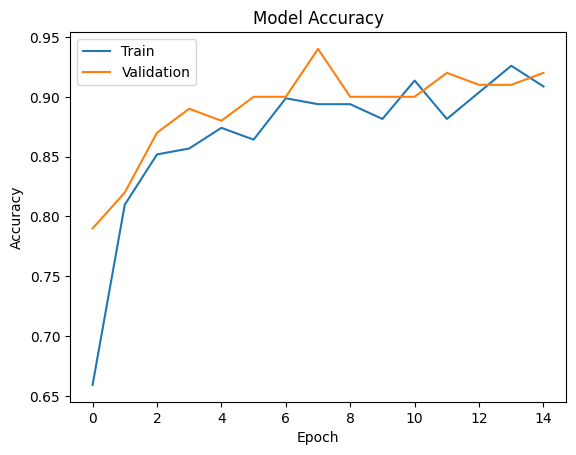

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

20. Loss Graph

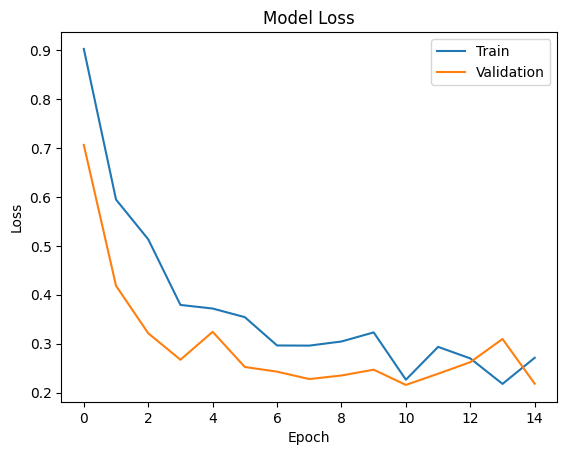

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

21. Precision / Recall / F1 Score

In [23]:
from sklearn.metrics import classification_report

predictions = model.predict(valid_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = valid_data.classes

class_labels = list(valid_data.class_indices.keys())

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 749ms/step
              precision    recall  f1-score   support

          NO       0.92      1.00      0.96        66
         RAO       1.00      0.75      0.86         4
         RVO       0.84      0.80      0.82        20
         VID       0.83      0.50      0.62        10

    accuracy                           0.90       100
   macro avg       0.90      0.76      0.81       100
weighted avg       0.90      0.90      0.89       100



22. Confusion Matrix

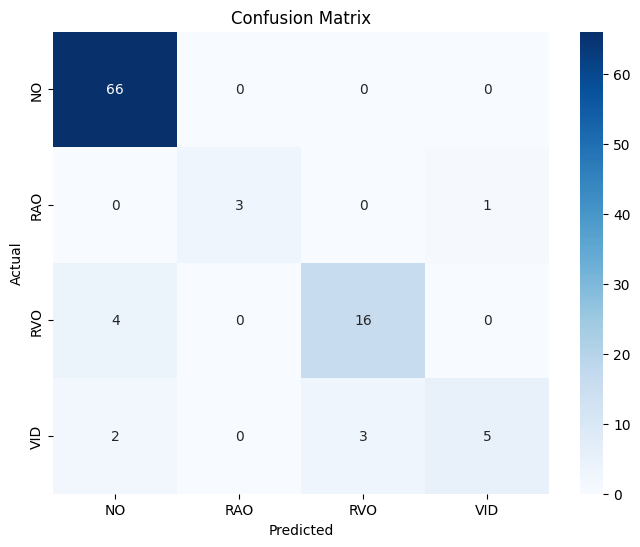

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

23. Save Model

In [25]:
model.save('OCT_Model.h5')

print("Model Saved Successfully")

Model Saved Successfully


24. Upload Test Image

In [27]:
from google.colab import files

uploaded = files.upload()

Saving archive (7).zip to archive (7) (1).zip


In [34]:
from google.colab import files

uploaded = files.upload()

Saving rao_1013386_2.jpg to rao_1013386_2 (1).jpg


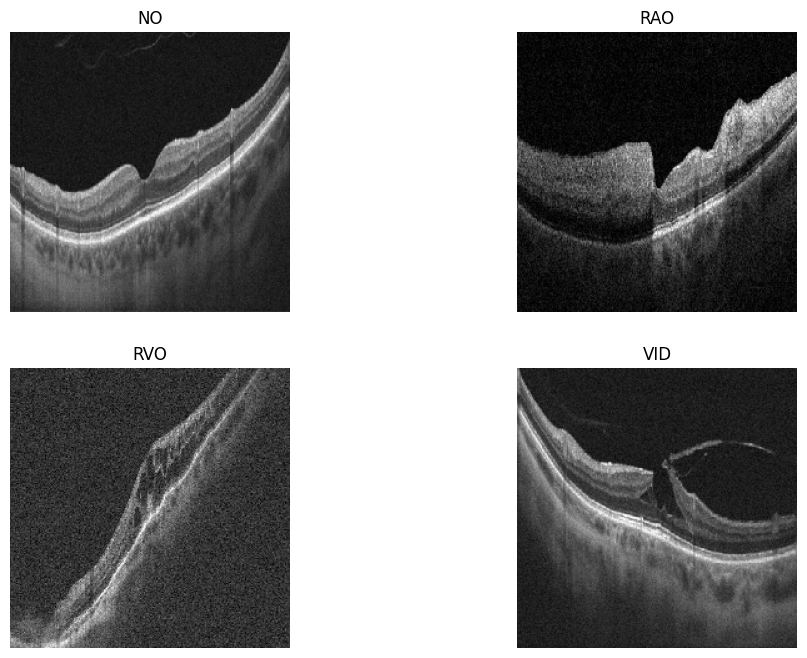

In [37]:
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image

base_path = '/content/dataset/OCTDL/OCTDL'

classes = ['NO', 'RAO', 'RVO', 'VID']

plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):

    class_folder = os.path.join(base_path, class_name)

    random_image = random.choice(os.listdir(class_folder))

    img_path = os.path.join(class_folder, random_image)

    img = image.load_img(img_path, target_size=(224,224))

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(class_name)

    plt.axis('off')

plt.show()

25. Test Single Image

In [29]:
from tensorflow.keras.preprocessing import image

img_path = '/content/rao_1013386_2.jpg'

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

labels = ['NO', 'RAO', 'RVO', 'VID']

print("Prediction:", labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction: RAO


WEB INTERFACE

In [30]:
import gradio as gr
from tensorflow.keras.models import load_model

27. Load Saved Model

In [31]:
model = load_model('/content/OCT_Model.h5')

28. Labels

In [32]:
labels = ['NO', 'RAO', 'RVO', 'VID']

29. Prediction Function

In [33]:
def predict_image(img):

    img = img.resize((224,224))

    img_array = np.array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_class = labels[np.argmax(prediction)]

    confidence = np.max(prediction) * 100

    return f'Prediction: {predicted_class}\\nConfidence: {confidence:.2f}%'

30. Create Interface

In [35]:
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type='pil'),
    outputs='text',
    title='OCT Disease Detection System',
    description='Upload OCT image for prediction'
)

31. Launch Web App

In [36]:
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d16a77abe44f3923e9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
